<a href="https://colab.research.google.com/github/antoniopedro98/antoniopsalves.github.io/blob/main/Resolvido_05_Prevendo_Posicao_Tabela_Brasileirao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Oficina de Inteligência Artificial Aplicada à Análise de Dados de Futebol**

# Projeto de Equipe - Previsão da Posição Final na Tabela (Brasileirão 2003–2024)

## O que vocês devem entregar

1. **Exploração do dataset (EDA)** com pelo menos **3 visualizações** (ex.: distribuição de pontos por temporada, pontos vs posição, posição média por time, etc.)
2. Um **modelo baseline** (algo simples, para comparação)
3. Um **modelo melhor** (ex.: Ridge, Random Forest)
4. Uma tabela com **métricas** e um gráfico **Real vs Previsto**
5. (Bônus) Um gráfico de **importância de atributos** do melhor modelo (se fizer sentido)

💡 **Dica importante:** aqui vamos transformar o dataset de *jogos* em um dataset de *time-temporada* (uma linha por time no campeonato). Ao construir essa tabela, cuidado para não incluir colunas que já “entregam” a resposta (ex.: a própria posição final).

## Importando as bibliotecas

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()


## Coleta dos dados

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/antoniopedro98/oficina-ia-puc-rio-2026-1/refs/heads/main/dataset_brasileirao_historico_2003_2024.csv", low_memory=False)
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,2005-08-28,23,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,São Paulo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,2005-06-26,9,Estádio Olímpico Nilton Santos,NaN,NaN,NaN,Botafogo,Figueirense FC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visão geral do dataset

In [ ]:
df.shape, df.dtypes.value_counts()

((8453, 35),
 float64    26
 object      7
 int64       2
 Name: count, dtype: int64)

In [ ]:
df.head()

,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,chutes_bola_parada_mandante,chutes_bola_parada_visitante,defesas_mandante,defesas_visitante,impedimentos_mandante,impedimentos_visitante,chutes_mandante,chutes_visitante,chutes_fora_mandante,chutes_fora_visitante
0,2005,2005-10-08,31,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Fluminense,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,2005-04-23,1,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Goiás EC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,2005-08-21,21,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,Vasco da Gama,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,2005-08-28,23,Estádio Durival Britto e Silva,NaN,NaN,NaN,Paraná,São Paulo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,2005-06-26,9,Estádio Olímpico Nilton Santos,NaN,NaN,NaN,Botafogo,Figueirense FC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano_campeonato,8453.0,NaN,NaN,NaN,2013.161481,6.36865,2003.0,2008.0,2013.0,2019.0,2024.0
data,8453,2107,2004-07-21,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rodada,8453.0,NaN,NaN,NaN,19.38649,10.924158,1.0,10.0,19.0,29.0,38.0
estadio,8442,84,Estádio Jornalista Mário Filho,798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arbitro,6743,209,Leandro Pedro Vuaden,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publico,6742.0,NaN,NaN,NaN,16189.951943,14074.412391,0.0,5898.25,12685.5,22963.25,82044.0
publico_max,4181.0,NaN,NaN,NaN,43910.461373,19838.986238,5000.0,24584.0,43600.0,57483.0,87101.0
time_mandante,8453,47,Flamengo,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_visitante,8453,47,Fluminense,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tecnico_mandante,6299,259,Cuca,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Preparação inicial

In [ ]:
# Convertendo a coluna de data (ajuda em análises e checagens)
df['data'] = pd.to_datetime(df['data'], errors='coerce', dayfirst=True)

# Vamos garantir que gols sejam numéricos (às vezes vêm como string)
for col in ['gols_mandante','gols_visitante']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[['ano_campeonato','data','time_mandante','time_visitante','gols_mandante','gols_visitante']].head()

,ano_campeonato,data,time_mandante,time_visitante,gols_mandante,gols_visitante
0,2005,2005-08-10,Paraná,Fluminense,6.0,1.0
1,2005,NaT,Paraná,Goiás EC,0.0,2.0
2,2005,NaT,Paraná,Vasco da Gama,0.0,0.0
3,2005,NaT,Paraná,São Paulo,0.0,4.0
4,2005,NaT,Botafogo,Figueirense FC,0.0,1.0


### Nulos (valores faltantes)

In [ ]:
null_pct = (df.isna().mean()*100).sort_values(ascending=False)
null_pct.head(15)

,0
chutes_fora_visitante,75.310541
defesas_visitante,75.310541
defesas_mandante,75.310541
faltas_mandante,75.310541
faltas_visitante,75.310541
chutes_bola_parada_visitante,75.310541
chutes_fora_mandante,75.310541
impedimentos_visitante,75.310541
impedimentos_mandante,75.310541
chutes_visitante,75.310541


In [ ]:
# Para este projeto, vamos manter apenas as colunas necessárias para construir a tabela final por time/temporada
cols_necessarias = [
    'ano_campeonato','data','rodada',
    'time_mandante','time_visitante',
    'gols_mandante','gols_visitante'
]
df_base = df[cols_necessarias].copy()
df_base.isna().mean().sort_values(ascending=False)

,0
data,0.611262
gols_mandante,0.000118
gols_visitante,0.000118
rodada,0.000000
ano_campeonato,0.000000
time_visitante,0.000000
time_mandante,0.000000


## Construindo a tabela *time-temporada*

O dataset original tem **1 linha por jogo**. Para prever a **posição final**, vamos criar um dataset com:

- **1 linha por time em uma temporada**
- Atributos como: jogos, vitórias, empates, derrotas, gols pró/contra, saldo, **pontos**
- E a variável alvo: **posição final** (1º, 2º, ..., 20º)

⚠️ Observação: o critério oficial de desempate pode ser mais complexo (ex.: vitórias, saldo, gols pró, etc.). Aqui vamos usar um critério **bem próximo e suficiente** para fins didáticos.

In [ ]:
# Função auxiliar: transforma cada jogo em 2 linhas (uma para mandante, outra para visitante)
def jogos_para_times(df_jogos: pd.DataFrame) -> pd.DataFrame:
    base = df_jogos.copy()

    # Resultado do jogo (pontos)
    gm = base['gols_mandante']
    gv = base['gols_visitante']

    # pontos mandante
    pts_m = np.where(gm > gv, 3, np.where(gm == gv, 1, 0))
    # pontos visitante
    pts_v = np.where(gv > gm, 3, np.where(gm == gv, 1, 0))

    mandante = pd.DataFrame({
        'ano_campeonato': base['ano_campeonato'],
        'time': base['time_mandante'],
        'gols_pro': gm,
        'gols_contra': gv,
        'pontos': pts_m,
        'vitorias': (gm > gv).astype(int),
        'empates': (gm == gv).astype(int),
        'derrotas': (gm < gv).astype(int),
        'jogos': 1
    })

    visitante = pd.DataFrame({
        'ano_campeonato': base['ano_campeonato'],
        'time': base['time_visitante'],
        'gols_pro': gv,
        'gols_contra': gm,
        'pontos': pts_v,
        'vitorias': (gv > gm).astype(int),
        'empates': (gm == gv).astype(int),
        'derrotas': (gv < gm).astype(int),
        'jogos': 1
    })

    return pd.concat([mandante, visitante], ignore_index=True)

df_times_jogos = jogos_para_times(df_base)
df_times_jogos.head()

,ano_campeonato,time,gols_pro,gols_contra,pontos,vitorias,empates,derrotas,jogos
0,2005,Paraná,6.0,1.0,3,1,0,0,1
1,2005,Paraná,0.0,2.0,0,0,0,1,1
2,2005,Paraná,0.0,0.0,1,0,1,0,1
3,2005,Paraná,0.0,4.0,0,0,0,1,1
4,2005,Botafogo,0.0,1.0,0,0,0,1,1


In [ ]:
# Agregando por time e temporada
df_team_season = (df_times_jogos
                 .groupby(['ano_campeonato','time'], as_index=False)
                 .agg({
                     'jogos':'sum',
                     'pontos':'sum',
                     'vitorias':'sum',
                     'empates':'sum',
                     'derrotas':'sum',
                     'gols_pro':'sum',
                     'gols_contra':'sum'
                 }))

df_team_season['saldo_gols'] = df_team_season['gols_pro'] - df_team_season['gols_contra']
df_team_season['pontos_por_jogo'] = df_team_season['pontos'] / df_team_season['jogos']

# Gerando a posição final aproximada por temporada
# Critério (didático): pontos, vitórias, saldo de gols, gols pró
df_team_season = df_team_season.sort_values(
    ['ano_campeonato','pontos','vitorias','saldo_gols','gols_pro'],
    ascending=[True, False, False, False, False]
)

df_team_season['posicao_final'] = df_team_season.groupby('ano_campeonato').cumcount() + 1

df_team_season.head(10)

,ano_campeonato,time,jogos,pontos,vitorias,empates,derrotas,gols_pro,gols_contra,saldo_gols,pontos_por_jogo,posicao_final
5,2003,Cruzeiro,38,76,23,7,8,78.0,42.0,36.0,2.000000,1
20,2003,Santos FC,38,70,20,10,8,73.0,48.0,25.0,1.842105,2
3,2003,Coritiba FC,38,65,19,8,11,59.0,46.0,13.0,1.710526,3
22,2003,São Paulo,38,62,17,11,10,68.0,57.0,11.0,1.631579,4
0,2003,Atlético-MG,38,62,16,14,8,66.0,52.0,14.0,1.631579,5
21,2003,São Caetano,38,59,15,14,9,40.0,30.0,10.0,1.552632,6
15,2003,Internacional,38,58,17,7,14,49.0,45.0,4.0,1.526316,7
4,2003,Criciúma EC,38,55,16,7,15,49.0,53.0,-4.0,1.447368,8
14,2003,Guarani,38,54,15,9,14,58.0,59.0,-1.0,1.421053,9
17,2003,Paraná,38,53,15,8,15,70.0,61.0,9.0,1.394737,10


### Checagens rápidas

In [ ]:
# Quantos times por temporada?
df_team_season.groupby('ano_campeonato')['time'].nunique().describe()

,time
count,22.000000
mean,20.454545
std,1.223861
min,20.000000
25%,20.000000
50%,20.000000
75%,20.000000
max,24.000000


In [ ]:
# Exemplo: top 5 de uma temporada
ano_exemplo = df_team_season['ano_campeonato'].max()
df_team_season[df_team_season['ano_campeonato']==ano_exemplo].head(5)

,ano_campeonato,time,jogos,pontos,vitorias,empates,derrotas,gols_pro,gols_contra,saldo_gols,pontos_por_jogo,posicao_final
433,2024,Botafogo,28,60,18,6,4,46.0,23.0,23.0,2.142857,1
446,2024,Palmeiras,29,55,16,7,6,48.0,23.0,25.0,1.896552,2
442,2024,Fortaleza,29,53,15,8,6,39.0,31.0,8.0,1.827586,3
448,2024,São Paulo,28,50,15,5,8,40.0,27.0,13.0,1.785714,4
440,2024,Flamengo,28,48,14,6,8,46.0,35.0,11.0,1.714286,5


## Exploração (EDA)

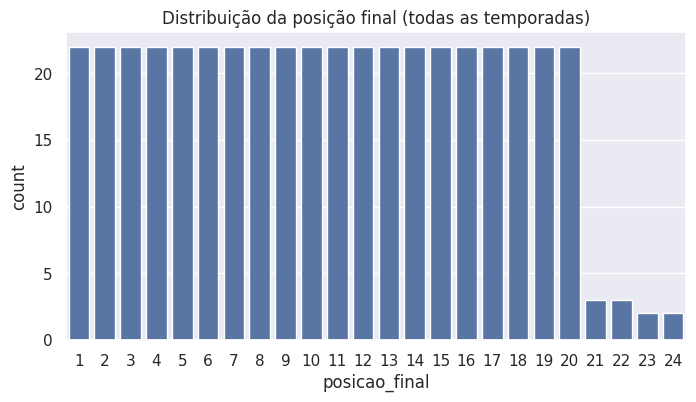

In [ ]:
# Distribuição de posições finais
plt.figure(figsize=(8,4))
sns.countplot(data=df_team_season, x='posicao_final')
plt.title('Distribuição da posição final (todas as temporadas)')
plt.show()

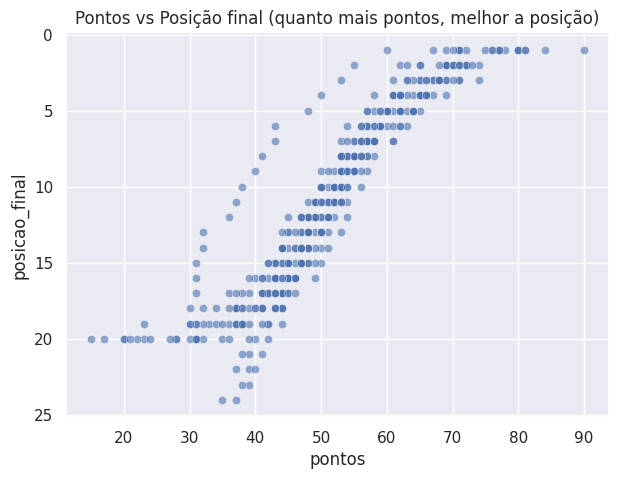

In [ ]:
# Relação: Pontos vs Posição final
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_team_season, x='pontos', y='posicao_final', alpha=0.6)
plt.gca().invert_yaxis()  # 1º lugar no topo
plt.title('Pontos vs Posição final (quanto mais pontos, melhor a posição)')
plt.show()

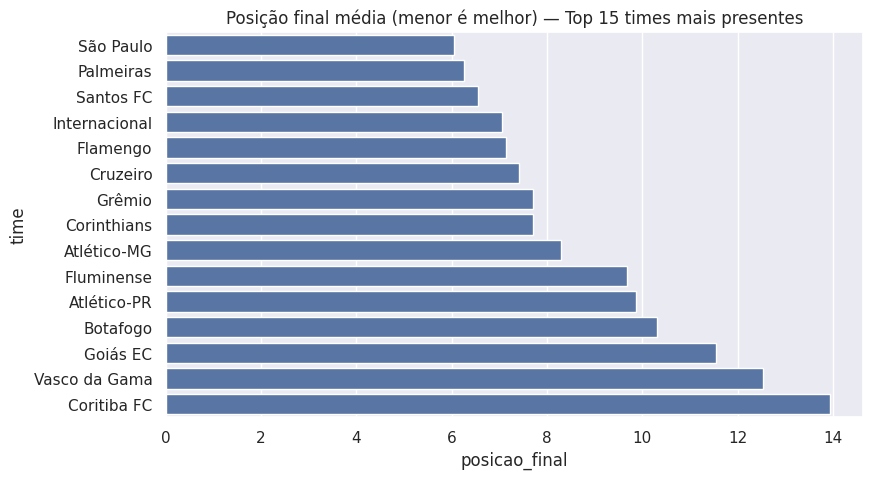

In [ ]:
# Posição média por time (top 15 times mais frequentes no dataset)
top_times = df_team_season['time'].value_counts().head(15).index
tmp = (df_team_season[df_team_season['time'].isin(top_times)]
       .groupby('time', as_index=False)['posicao_final'].mean()
       .sort_values('posicao_final'))
plt.figure(figsize=(9,5))
sns.barplot(data=tmp, y='time', x='posicao_final')
plt.title('Posição final média (menor é melhor) — Top 15 times mais presentes')
plt.show()

## Engenharia de atributos (features)

In [ ]:
# Definindo features (X) e alvo (y)
target = 'posicao_final'

# Aqui vamos usar um conjunto simples e interpretável de atributos
feature_cols = [
    'ano_campeonato',
    'time',
    'jogos',
    'pontos',
    'vitorias',
    'empates',
    'derrotas',
    'gols_pro',
    'gols_contra',
    'saldo_gols',
    'pontos_por_jogo'
]

df_model = df_team_season[feature_cols + [target]].copy()
df_model.head()

,ano_campeonato,time,jogos,pontos,vitorias,empates,derrotas,gols_pro,gols_contra,saldo_gols,pontos_por_jogo,posicao_final
5,2003,Cruzeiro,38,76,23,7,8,78.0,42.0,36.0,2.000000,1
20,2003,Santos FC,38,70,20,10,8,73.0,48.0,25.0,1.842105,2
3,2003,Coritiba FC,38,65,19,8,11,59.0,46.0,13.0,1.710526,3
22,2003,São Paulo,38,62,17,11,10,68.0,57.0,11.0,1.631579,4
0,2003,Atlético-MG,38,62,16,14,8,66.0,52.0,14.0,1.631579,5


## Separando treino e teste (temporal)

In [ ]:
# Vamos treinar em anos antigos e testar nos anos mais recentes (2023-2024)
train_mask = df_model['ano_campeonato'] <= 2022
test_mask  = df_model['ano_campeonato'] >= 2023

train_df = df_model[train_mask].copy()
test_df  = df_model[test_mask].copy()

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

X_train.shape, X_test.shape

((410, 11), (40, 11))

## Pré-processamento (Pipeline)

In [ ]:
# Separando colunas numéricas e categóricas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    remainder='drop'
)

num_cols, cat_cols

(['ano_campeonato',
  'jogos',
  'pontos',
  'vitorias',
  'empates',
  'derrotas',
  'gols_pro',
  'gols_contra',
  'saldo_gols',
  'pontos_por_jogo'],
 ['time'])

## Função de avaliação

In [ ]:
def avaliar_regressao(y_true, y_pred, nome_modelo='modelo'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([{
        'modelo': nome_modelo,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }])

def treinar_e_avaliar(model, nome, X_train, y_train, X_test, y_test):
    pipe = Pipeline(steps=[('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, avaliar_regressao(y_test, pred, nome), pred

## Baseline

In [ ]:
baseline_model = DummyRegressor(strategy='mean')
baseline_pipe, baseline_metrics, baseline_pred = treinar_e_avaliar(
    baseline_model, 'Dummy(mean)', X_train, y_train, X_test, y_test
)
baseline_metrics

,modelo,MAE,RMSE,R2
0,Dummy(mean),5.0,5.773459,-0.002491


## Modelo 1 — Ridge

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_pipe, ridge_metrics, ridge_pred = treinar_e_avaliar(
    ridge_model, 'Ridge', X_train, y_train, X_test, y_test
)
ridge_metrics

,modelo,MAE,RMSE,R2
0,Ridge,1.34722,1.561305,0.926687


## Modelo 2 — Random Forest (pode demorar um pouco)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=1
)
rf_pipe, rf_metrics, rf_pred = treinar_e_avaliar(
    rf_model, 'RandomForest', X_train, y_train, X_test, y_test
)
rf_metrics

,modelo,MAE,RMSE,R2
0,RandomForest,1.776563,2.218108,0.85203


## Comparando os modelos

In [ ]:
results = pd.concat([baseline_metrics, ridge_metrics, rf_metrics], ignore_index=True)
results.sort_values('RMSE')

,modelo,MAE,RMSE,R2
1,Ridge,1.347220,1.561305,0.926687
2,RandomForest,1.776563,2.218108,0.852030
0,Dummy(mean),5.000000,5.773459,-0.002491


## Real vs Previsto (melhor modelo no teste)

In [ ]:
# Vamos escolher o melhor pelo menor RMSE
best_name = results.sort_values('RMSE').iloc[0]['modelo']
best_name

'Ridge'

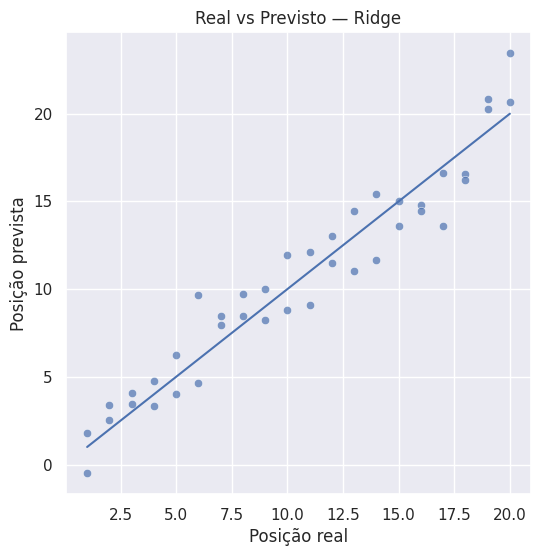

In [ ]:
# Selecionando predições do melhor modelo
pred_map = {
    'Dummy(mean)': baseline_pred,
    'Ridge': ridge_pred,
    'RandomForest': rf_pred
}
best_pred = pred_map[best_name]

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.7)
plt.xlabel("Posição real")
plt.ylabel("Posição prevista")
plt.title(f"Real vs Previsto — {best_name}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

# Conclusão

Neste projeto, vocês:

- Transformaram uma base de **jogos** em uma base de **time-temporada**
- Construíram um alvo (posição final) a partir de **pontos e critérios de desempate**
- Fizeram EDA com visualizações para entender padrões
- Treinaram um baseline e modelos melhores, comparando com métricas

📌 Próximos passos (se sobrar tempo):
- testar **outros splits temporais** (ex.: treino até 2019, teste 2020–2024)
- prever **faixas de classificação** (ex.: G4, meio da tabela, Z4) como *classificação*
- incluir atributos “de contexto” (ex.: valor do elenco, idade média), se existirem em outras bases